# Stage 5: Mô hình Backbone (Transfer Learning) - Tối ưu hóa & Huấn luyện

In [8]:
import sys, os, gc, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import optuna

# Thêm đường dẫn tới thư mục gốc
sys.path.append(os.path.dirname(os.getcwd()))

from utils.config import Config, Params
from utils.data import get_dataloaders
from utils.train import fit
from utils.recipe import build_criterion, build_scheduler, make_param_groups
from utils.evaluate import plot_training_history, evaluate_test_set, plot_misclassified_samples
from models.backbone_model import EfficientNetB0_Transfer

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

config = Config()
device = config.DEVICE
print(f"Sử dụng thiết bị: {device}")

STAGE = "backbone"
OUT_DIR = f"../output/{STAGE}"
os.makedirs(OUT_DIR, exist_ok=True)

Sử dụng thiết bị: xpu


In [9]:
# Lấy Dataloaders
train_loader, val_loader, test_loader, class_names = get_dataloaders(img_size=config.IMG_SIZE)
print(f"Số lượng classes: {len(class_names)} ({class_names})")

[*] Tìm thấy cache trong RAM cho 'train', sử dụng lại dữ liệu (8299 ảnh)...
[*] Tìm thấy cache trong RAM cho 'val', sử dụng lại dữ liệu (2948 ảnh)...
[*] Tập test nạp trực tiếp từ ổ cứng (không dùng Cache RAM).
Số lượng classes: 2 (['real', 'spoof'])


In [10]:
# Lấy cấu hình tối ưu từ stage trước (có thể dùng lại parameters của optimize)
recipe = Params.load_recipe("optimize")
print("Recipe được load:", json.dumps(recipe, indent=2))

EPOCHS_MINI = 6
EPOCHS_FINAL = 30
N_TRIALS = 8
SEED = 42

Recipe được load: {
  "loss_type": "ce",
  "gamma": null,
  "label_smoothing": 0.029122914019804193,
  "weight_decay": 0.00039605150456850803,
  "scheduler": "cosine",
  "selection_metric": "acer_at_eer",
  "sampler": "balanced",
  "lr_hint": 0.0002241521242372111
}


## Mini-sweep: Tìm Learning Rate phù hợp cho Backbone Model

In [11]:
def run_training(lr, epochs, experiment_name, seed, trial=None):
    set_seed(seed)
    model = EfficientNetB0_Transfer(num_classes=len(class_names), pretrained=True, freeze_backbone=False, dropout=0.45).to(device)
    
    # Sử dụng nhóm tham số để không áp dụng weight decay cho bias/batchnorm
    wd = recipe.get("weight_decay", 1e-4)
    param_groups = make_param_groups(model, lr=lr, weight_decay=wd)
    optimizer = optim.AdamW(param_groups)
    
    # Kế thừa hàm loss từ recipe
    criterion = build_criterion(recipe)
    
    # Scheduler
    scheduler = build_scheduler(optimizer, epochs, {"scheduler": "cosine", "warmup_epochs": 1})
    
    model, history = fit(model, train_loader, val_loader, criterion, optimizer, device, class_names,
                         epochs=epochs, config=config, scheduler=scheduler,
                         experiment_name=experiment_name, trial=trial)
    return model, history

def score_of(history):
    return float(np.mean(history['val_acer'][-3:]))

def objective(trial):
    # Khảo sát quanh lr_hint của recipe (Backbone thường cần LR nhỏ hơn do pre-trained)
    lr_hint = recipe.get("lr_hint", 4e-4) / 5.0 # Mặc định Transfer learning LR sẽ nhỏ hơn train from scratch
    lr = trial.suggest_float("lr", lr_hint / 10, lr_hint * 5, log=True)
    
    model, history = run_training(lr, EPOCHS_MINI, f"{STAGE}/trial_{trial.number}", seed=SEED + trial.number, trial=trial)
    
    # Thu gọn bộ nhớ (Không gọi empty_cache để tránh lỗi driver XPU)
    del model; gc.collect()
    
    return score_of(history)

In [12]:
# Chạy quét tham số
import shutil

study_name = f"{STAGE}_study"
storage_name = f"sqlite:///{OUT_DIR}/{study_name}.db"

# Khởi tạo study có lưu trữ xuống ổ cứng để tự động resume nếu bị ngắt quãng
study = optuna.create_study(study_name=study_name, storage=storage_name, load_if_exists=True, direction="minimize")

# Chỉ enqueue nếu study mới tinh chưa có trial nào
if len(study.trials) == 0:
    study.enqueue_trial({"lr": recipe.get("lr_hint", 4e-4) / 5.0})

study.optimize(objective, n_trials=N_TRIALS)

df = study.trials_dataframe()
display_cols = [c for c in ['number', 'value', 'state', 'params_lr'] if c in df.columns]
display(df[display_cols].sort_values('value').head())

# ==============================================================================
# BƯỚC RECHECK VÀ CHỌN LR AN TOÀN CHO HUẤN LUYỆN DÀI (30 EPOCHS)
# ==============================================================================
done_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
top_trials = sorted(done_trials, key=lambda t: t.value)[:3]

recheck = []
print("\n[*] Bắt đầu recheck top 3 trials bằng seed khác...")
for rank, t in enumerate(top_trials):
    lr = t.params["lr"]
    _, h = run_training(lr, EPOCHS_MINI, f"{STAGE}/recheck_{rank}", seed=SEED + 1000 + rank)
    recheck_score = score_of(h)
    avg_score = (t.value + recheck_score) / 2
    recheck.append((t, avg_score))
    print(f"Trial {t.number} (lr={lr:.2e}): Lần 1 = {t.value:.4f} | Lần 2 = {recheck_score:.4f} | Trung bình = {avg_score:.4f}")
    del _ ; gc.collect()

# Tìm best score
best_score = min(r[1] for r in recheck)
good_candidates = [r for r in recheck if r[1] - best_score <= 0.01]

import math
candidate_lrs = [r[0].params["lr"] for r in good_candidates]
geometric_mean_lr = math.exp(sum(math.log(lr) for lr in candidate_lrs) / len(candidate_lrs))
best_lr = geometric_mean_lr / 1.5

print(f"[*] Best ACER: {best_score:.4f}")
print(f"[*] Các LR tương đương (chênh < 0.01): {[f'{lr:.2e}' for lr in candidate_lrs]}")
print(f"[*] LR trung bình nhân: {geometric_mean_lr:.2e}")
print(f"[*] LR chốt cuối cùng (đã giảm 1.5x để an toàn cho 30 epochs): {best_lr:.2e}")

[I 2026-10-08 13:03:47,014] A new study created in RDB with name: backbone_study


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/backbone/trial_0/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.


[I 2026-10-08 13:03:47,939] Trial 0 finished with value: 0.057774994376558586 and parameters: {'lr': 4.483042484744222e-05}. Best is trial 0 with value: 0.057774994376558586.


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/backbone/trial_1/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.


[I 2026-10-08 13:03:48,763] Trial 1 finished with value: 0.14760926872605992 and parameters: {'lr': 3.41474925208165e-05}. Best is trial 0 with value: 0.057774994376558586.


...

Epoch 02/6 | Train Loss/Acc: 0.6502/0.6203 | Val Loss/Acc: 0.5733/0.7466 | APCER/BPCER/ACER: 0.2595/0.2593/0.2594 | AUC: 0.8224 | ACER@0.5: 0.2600 | Threshold: 0.5050 ⭐ [BEST]


Epoch 03/6 | Train Loss/Acc: 0.5257/0.7646 | Val Loss/Acc: 0.5620/0.7164 | APCER/BPCER/ACER: 0.2320/0.2321/0.2321 | AUC: 0.8552 | ACER@0.5: 0.2422 | Threshold: 0.4564 ⭐ [BEST]


Epoch 04/6 | Train Loss/Acc: 0.4415/0.8284 | Val Loss/Acc: 0.4622/0.7985 | APCER/BPCER/ACER: 0.2021/0.2025/0.2023 | AUC: 0.8855 | ACER@0.5: 0.2029 | Threshold: 0.5009 ⭐ [BEST]


Epoch 05/6 | Train Loss/Acc: 0.3898/0.8586 | Val Loss/Acc: 0.4924/0.7663 | APCER/BPCER/ACER: 0.2017/0.2025/0.2021 | AUC: 0.8900 | ACER@0.5: 0.2092 | Threshold: 0.4506 ⭐ [BEST]


Epoch 06/6 | Train Loss/Acc: 0.3575/0.8752 | Val Loss/Acc: 0.4504/0.8002 | APCER/BPCER/ACER: 0.1872/0.1877/0.1874 | AUC: 0.8997 | ACER@0.5: 0.1905 | Threshold: 0.4798 ⭐ [BEST]

[+] Quá trình huấn luyện hoàn tất!
[*] Đang tải lại trọng số của mô hình tốt nhất (Best Model) để đánh giá...
Trial 3 (lr=5.57e-06): Lần 1 = 0.0404 | Lần 2 = 0.1973 | Trung bình = 0.1188
[*] Best ACER: 0.0361
[*] Các LR tương đương (chênh < 0.01): ['1.80e-04']
[*] LR trung bình nhân: 1.80e-04
[*] LR chốt cuối cùng (đã giảm 1.5x để an toàn cho 30 epochs): 1.20e-04


## Huấn luyện mô hình cuối cùng (Final Training)

In [13]:
# Gán cứng best_lr để chạy trực tiếp nếu không chạy phần Sweep
best_lr = 5.25e-05  # Bạn có thể thay đổi bằng con số tìm được từ phần Sweep
print(f"Bắt đầu huấn luyện Final với LR: {best_lr:.2e}")

# Huấn luyện mô hình với LR tốt nhất
best_model, history = run_training(best_lr, EPOCHS_FINAL, f"{STAGE}/final", seed=SEED)

import numpy as np
best_epoch_idx = int(np.argmin(history['val_acer'])) if len(history['val_acer']) > 0 else 0
best_threshold = history['val_eer_threshold'][best_epoch_idx] if len(history['val_eer_threshold']) > 0 else 0.5

print(f"Epoch tốt nhất: {best_epoch_idx+1} | ACER val: {history['val_acer'][best_epoch_idx]:.4f} | ngưỡng: {best_threshold:.4f}")

Bắt đầu huấn luyện Final với LR: 5.25e-05
[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/backbone/final/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 31.
[*] Quá trình huấn luyện đã hoàn tất đủ 30 epochs từ trước.
Epoch tốt nhất: 17 | ACER val: 0.0154 | ngưỡng: 0.8682


## Đánh giá và lưu mô hình

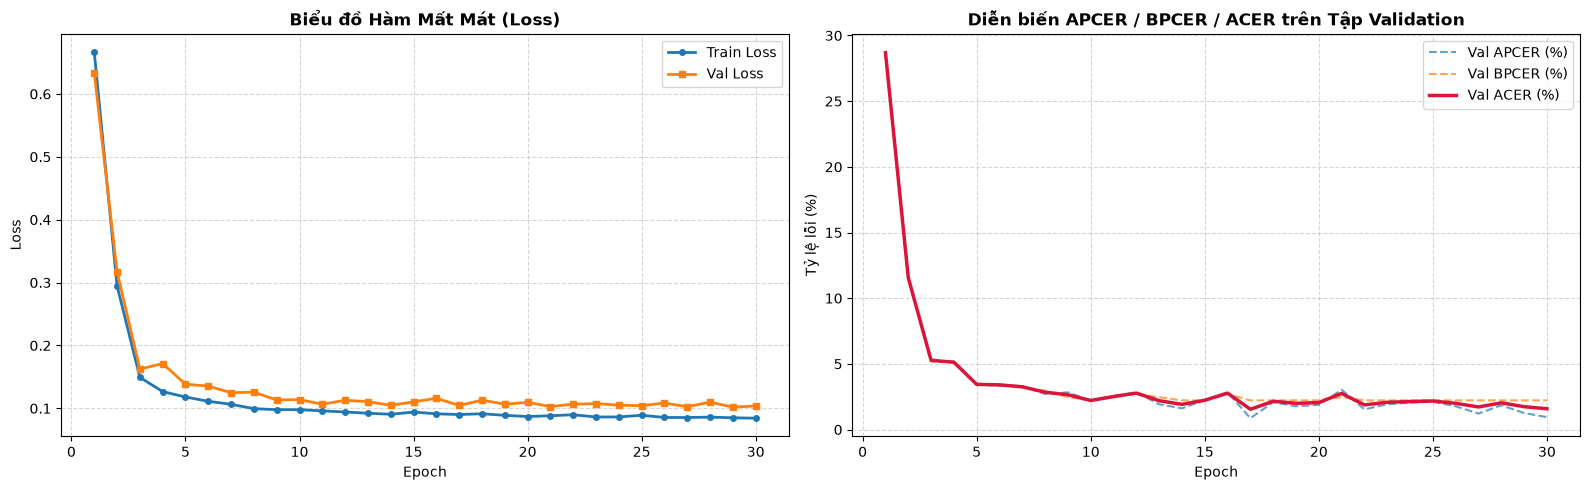

[*] Thu thập kết quả dự đoán trên tập Val...


[*] Thu thập kết quả dự đoán trên tập Test...


✅ Đánh giá xong! F1-Score trên tập Test: 0.9851 (Threshold = 0.8682)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        real       0.60      0.94      0.73       314
       spoof       1.00      0.97      0.99      7266

    accuracy                           0.97      7580
   macro avg       0.80      0.95      0.86      7580
weighted avg       0.98      0.97      0.97      7580

-----------------------------



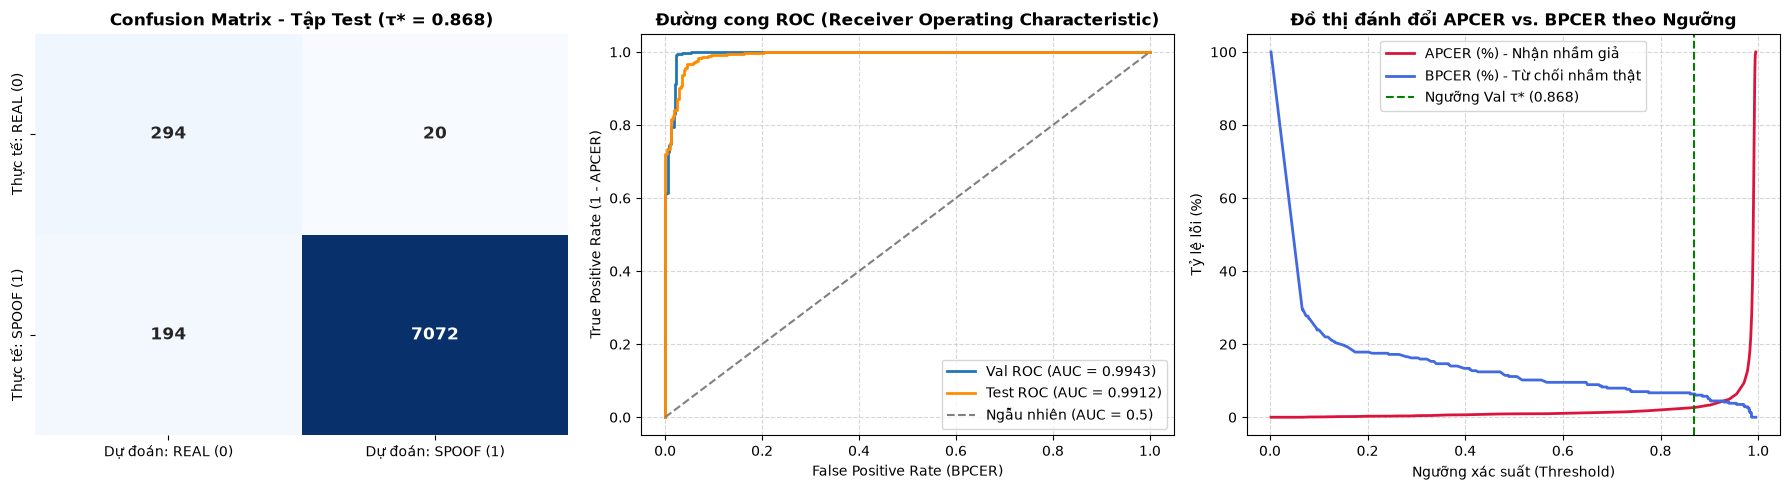

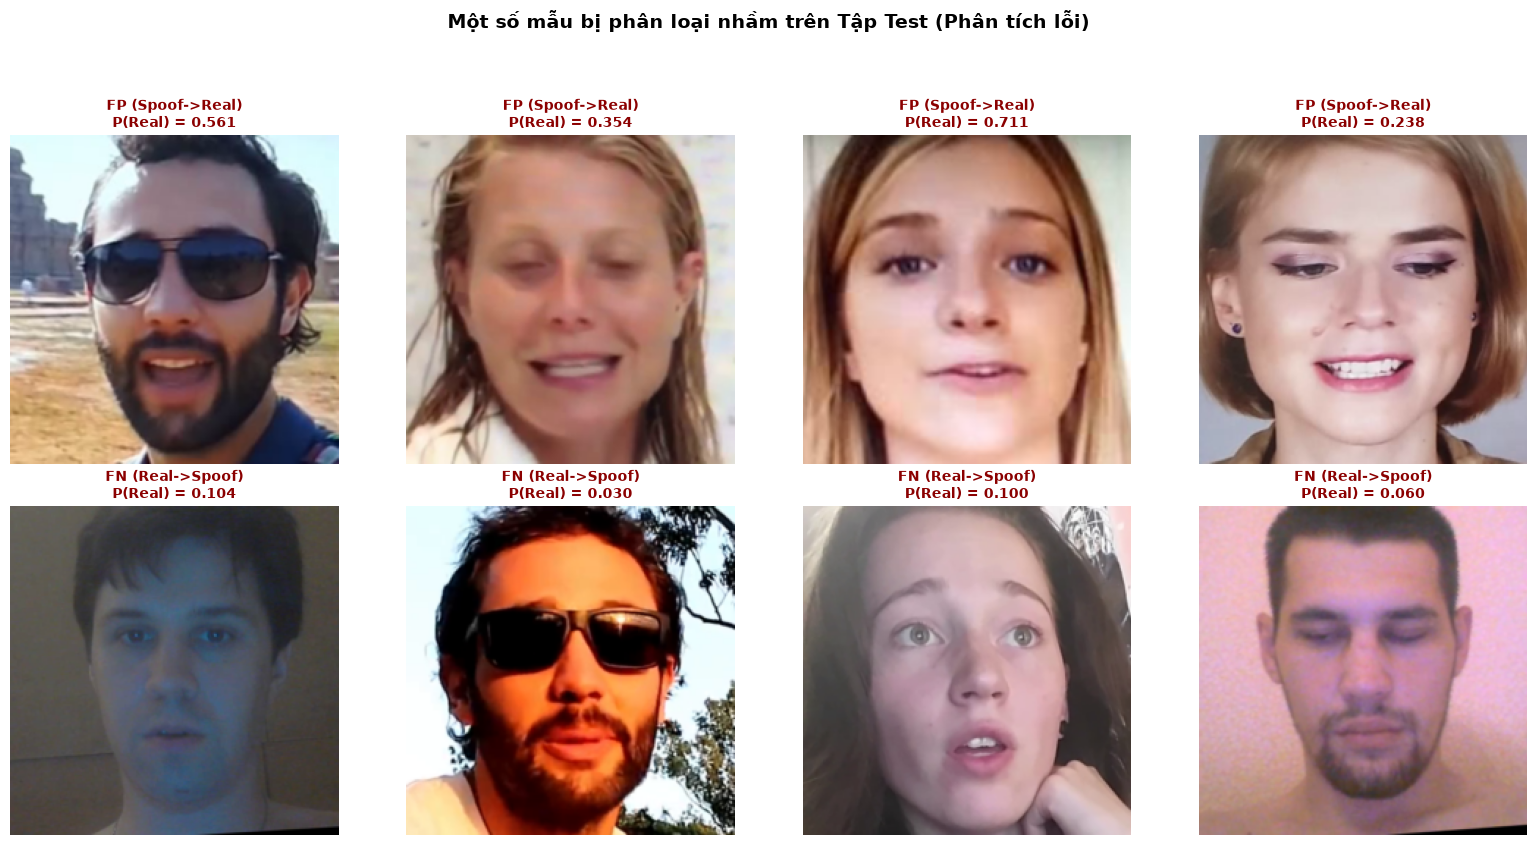

In [14]:
plot_training_history(history, save_dir=OUT_DIR)

test_probs, test_labels, test_preds = evaluate_test_set(
    best_model, val_loader, test_loader, device, class_names, 
    threshold=best_threshold, save_dir=OUT_DIR
)

plot_misclassified_samples(
    test_loader.dataset, test_probs, test_preds, test_labels, class_names, 
    num_samples=4, save_dir=OUT_DIR
)

In [15]:
OUT_MODEL_DIR = "../output/models/backbone"
os.makedirs(OUT_MODEL_DIR, exist_ok=True)
onnx_path = os.path.join(OUT_MODEL_DIR, "backbone_model.onnx")

best_model.eval()
dummy_input = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE, device=device)

torch.onnx.export(
    best_model, 
    dummy_input, 
    onnx_path, 
    input_names=['input'], 
    output_names=['output']
)
print(f"Đã xuất mô hình ONNX thành công tại: {onnx_path}")

[torch.onnx] Obtain model graph for `EfficientNetB0_Transfer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNetB0_Transfer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Đã xuất mô hình ONNX thành công tại: ../output/models/backbone/backbone_model.onnx
